### Import necessary modules

In [32]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from obspy import Stream, Trace, UTCDateTime, read
from obspy.clients.fdsn import Client
from obspy.geodetics import gps2dist_azimuth
from scipy.signal.windows import blackmanharris
from scipy.linalg import block_diag
from obspy.core.inventory import Network, Inventory

from lsforce import LSData, LSForce, LSTrajectory, make_lsdata_syn
from bayesian import *
from obspy.imaging.scripts.mopad import MomentTensor as MopadMT

import warnings

warnings.filterwarnings(
    action='ignore', message='FigureCanvasAgg is non-interactive', category=UserWarning
)

### 21 August 2009 Glacial Earthquake in Greenland

/var/folders/b9/lhhdkk4n2jv5c7hbkg_l89pr0000gn/T/ipykernel_26460/1694500010.py:39: ObsPyDeprecationWarning: attach_response is deprecated and will be removed in a future release. Use remove_response() instead.
  st = client.get_waveforms(


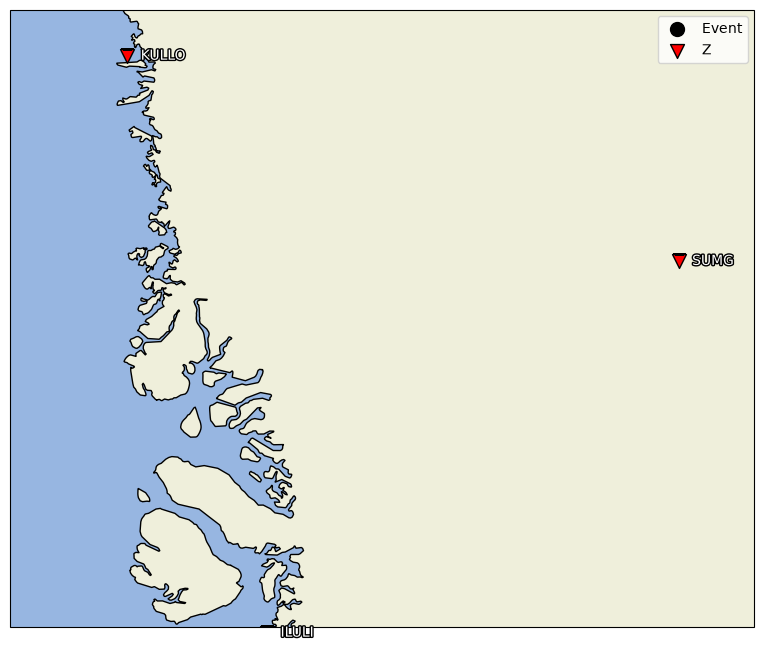

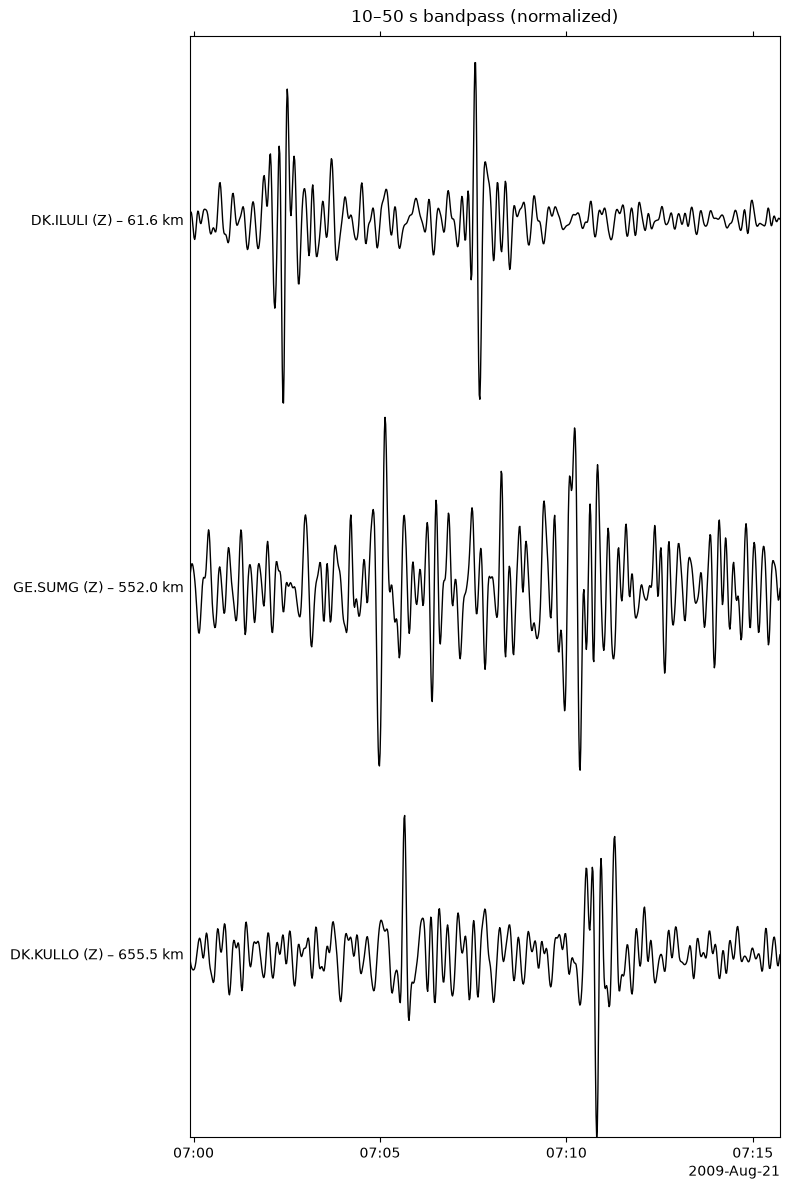

In [ ]:
PERIOD_RANGE = (10, 50)  

LS_LAT, LS_LON = (69.2, -49.55) 
ORIGIN_TIME = UTCDateTime(2009, 8, 21, 7, 2, 24)

STARTTIME = ORIGIN_TIME - 150
ENDTIME = ORIGIN_TIME + 800

main_folder = Path.cwd() / 'folder_name_here'
if not main_folder.exists():
    main_folder.mkdir()

EVENTS = [
    dict(name='2009', starttime=STARTTIME, endtime=ENDTIME, lat=LS_LAT, lon=LS_LON),
]

#import Z-components of event 
Num_channels=3
results = {}

for ev in EVENTS:
    data_filename = main_folder / f"data_{ev['name']}.pkl"
    data_filename.unlink(missing_ok=True)
    
    if not data_filename.exists():
        client = Client('GFZ')
        waveform_kwargs = dict(
            location='', starttime=ev['starttime'], endtime=ev['endtime'], attach_response=True
        )
        NETWORKS = (
            'DK', 
            'GE', 
            )
        STATIONS = (
            'ILULI', 
            'KULLO', 
            'SUMG', 
        )

        st = client.get_waveforms(
            network=','.join(NETWORKS),
            station=','.join(STATIONS),
            channel='LHZ, LNZ',
            **waveform_kwargs,
        )
        

        inv = client.get_stations(
            network=','.join(NETWORKS),
            starttime=ev['starttime'],
            endtime=ev['endtime'],
            level='channel',
        )

        unique_keys = set()
        clean_st=Stream()
        for tr in st:
            key = f"{tr.stats.station}.{tr.stats.channel}"
            if key not in unique_keys:
                unique_keys.add(key)
                clean_st.append(tr)

        st = clean_st

        #clean up data
        st.detrend('demean')
        st.detrend('linear')
        
        for tr in st:
            coords = inv.get_coordinates(tr.id, datetime=ev['starttime'])
            tr.stats.latitude = coords['latitude']
            tr.stats.longitude = coords['longitude']
        
        st.write(str(data_filename), format='PICKLE')

    else:
        st = read(str(data_filename), format='PICKLE')

    assert st.count() == Num_channels, f"Not the correct number of channels for {ev['name']}."


    freqmin = 1 / PERIOD_RANGE[1]
    freqmax = 1 / PERIOD_RANGE[0]
    taper_frac = 0.5
    f1 = freqmin * (1 - taper_frac)
    f4 = freqmax * (1 + taper_frac)
    pre_filt = (f1, freqmin, freqmax, f4)

    data = LSData(st, source_lat=ev['lat'], source_lon=ev['lon'], remove_response=True, remove_response_kwargs=dict(pre_filt=pre_filt))
    data.plot_stations(label_stations=True)
    data.plot_data(equal_scale=False, period_range=PERIOD_RANGE)

    results[ev['name']] = data

### Setup

In [ ]:
#retreive Green's functions (both force and moment)
both = LSForce(
    data=data, data_sampling_rate=1, main_folder=main_folder
)

both.setup(
    period_range=PERIOD_RANGE,
    syngine_model='iasp91_2s',
    source_type='both', 
    skip_datafilter=True
)

st_combined=both.data.st_proc.copy()

Getting Green's functions...
Found N19K (1/6)
Found O18K (2/6)
Found O19K (3/6)
Found O20K (4/6)
Found P19K (5/6)
Found Q19K (6/6)
Found N19K (1/6)
Found O18K (2/6)
Downloaded O19K (3/6)
Downloaded O20K (4/6)
Downloaded P19K (5/6)
Downloaded Q19K (6/6)


### Bayesian Inversion

In [ ]:
#force only inversion
test_f = LSForce(data=data, data_sampling_rate=1, main_folder=main_folder)

st_noise = test_f.data.st_proc.copy()
st_noise.resample(test_f.data_sampling_rate, window='hann')

#sample noise from desired window
noise_window = 100
start= UTCDateTime('2009-08-21T07:00:00')
noise_variances=noise_variance(st_noise, noise_window, 
    event_starttime=start, 
    event_endtime= start+ noise_window)

test_f.setup(
    period_range=PERIOD_RANGE,
    syngine_model='iasp91_2s',
    source_type='force',
    skip_datafilter=True
)

dt=1
corr_length=5
nugget=1e-6
force_mag=5e10
theta=299
uncertainty=[0.2, 0.2, 0.2]
n = test_f.G.shape[1]
m_prior = np.zeros(n)
m_force, Cm_post_f, Cd_f, misfit_f, misfit_norm_f, model_norm_f, term1_f, bic_f, evidence_f=force_bayesian(test_f, theta, force_mag, uncertainty,dt, nugget, corr_length, m_prior, noise_variances)

#have to define and pass a "fake force" for the plotting function, will not show up in actual code
components = ['fake_force_z', 'fake_force_n', 'fake_force_e', 'fake_mrr', 'fake_mtt', 'fake_mpp', 'fake_mrt', 'fake_mrp', 'fake_mtp']
globals().update({name: np.zeros(950) for name in components})
given_forces=[fake_force_z, fake_force_n, fake_force_e]
component_labels=['Z', 'N', 'E']
fig, F_z, F_e, F_n = force_bayesian_plot(m_force, dt, Cm_post_f, given_forces, component_labels, test='no');


stations = sorted(set((tr.stats.network, tr.stats.station) for tr in st_combined))
components = ['Z', 'R', 'T']
st_obs_filt = test_f.data.st_proc.copy()
_, _, vr_records_force = single_bayesian_forward(test_f, m_force, stations, components, st_obs_filt, 950);

Getting Green's functions...
Found ILULI (1/3)
Found KULLO (2/3)
Found SUMG (3/3)
Log Evidence: 43466.820583241126


In [ ]:
#moment only inversion
test_m = LSForce(data=data, data_sampling_rate=1, main_folder=main_folder)
st_noise = test_m.data.st_proc.copy()
st_noise.resample(test_m.data_sampling_rate, window='hann')

test_m.setup(
    period_range=PERIOD_RANGE,
    syngine_model='iasp91_2s',
    source_type='moment',
    skip_datafilter=True
)


n = test_m.G.shape[1]
m_prior = np.zeros(n)
corr_length=5
uncertainty=.1
mw=4.8
dt=1
nugget=1e-6
m_moment, Cm_post_moment, Cd_m, misfit_m, _, _,  bic_moment, evidence_m= moment_bayesian(test_m, mw, uncertainty, dt, nugget, corr_length, m_prior, noise_variances);

mt_labels = ['Mrr', 'Mtt', 'Mpp', 'Mrt', 'Mrp', 'Mtp']
given_moment=[fake_mrr, fake_mtt, fake_mpp, fake_mrt, fake_mrp, fake_mtp]
moment_bayesian_plot(m_moment, dt, Cm_post_moment, given_moment, mt_labels, test='no');


stations = sorted(set((tr.stats.network, tr.stats.station) for tr in st_combined))
components = ['Z', 'R', 'T']
st_obs_filt = test_m.data.st_proc.copy()
_, _, vr_records_moment = single_bayesian_forward(test_m, m_moment, stations, components, st_obs_filt, 950);

Getting Green's functions...
Downloaded N19K (1/6)
Downloaded O18K (2/6)
Downloaded O19K (3/6)
Downloaded O20K (4/6)
Downloaded P19K (5/6)
Downloaded Q19K (6/6)
Log Evidence: 63007.75499137881


In [ ]:
#joint inversion
test = LSForce(data=data, data_sampling_rate=1, main_folder=main_folder)


test.setup(
    period_range=PERIOD_RANGE,
    syngine_model='iasp91_2s',
    source_type='both',
    skip_datafilter=True
)
dt=1
nugget=1e-8
force_mag=5e10
theta=299
uncertainty_f=[.1, .1, .1]
uncertainty_m=0.1
mw=2.8
corr_length_f=10
corr_length_m=200
n = test.G.shape[1]
m_prior = np.zeros(n)
m_both, Cm_post_both, _, _, _, bic_both, evidence_b=joint_bayesian(test, theta, force_mag, mw, uncertainty_f, uncertainty_m, dt, nugget, corr_length_f, corr_length_m, m_prior, noise_variances);
component_labels = ['Z', 'N', 'E', 'Mrr', 'Mtt', 'Mpp', 'Mrt', 'Mrp', 'Mtp']
given=[fake_force_z, fake_force_n, fake_force_e, fake_mrr, fake_mtt, fake_mpp, fake_mrt, fake_mrp, fake_mtp]
joint_plots(component_labels, m_both, m_force, m_moment, Cm_post_both, dt, given, test='no');

components = ['Z', 'R', 'T']
st_obs_filt = test.data.st_proc.copy()
stations = sorted(set((tr.stats.network, tr.stats.station) for tr in st_obs_filt))
single_bayesian_forward(test, m_both, stations, components, st_obs_filt, 950);

Getting Green's functions...
Found N19K (1/6)
Found O18K (2/6)
Found O19K (3/6)
Found O20K (4/6)
Found P19K (5/6)
Found Q19K (6/6)
Found N19K (1/6)
Found O18K (2/6)
Found O19K (3/6)
Found O20K (4/6)
Found P19K (5/6)
Found Q19K (6/6)
Log Evidence: 67441.90178630079


In [ ]:
#evidence comparison
evidence_table = pd.DataFrame({
    'Scheme': ['Force', 'Moment', 'Joint'],
    'Evidence': [evidence_f, evidence_m, evidence_b],
})

print(evidence_table)

   Scheme      Evidence
0   Force  43466.820583
1  Moment  42526.540976
2   Joint  42525.478723
